In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.9 MB 13.1 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.9 MB 12.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 11.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_pickle('G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl')
df.head()

,Date,Primary Type,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,...,Hour,Is_Weekend,Season,Lat_bin,Lon_bin,Crime_Severity_Score,Location_Desc_freq,Primary Type_freq,Latitude_Norm,Longitude_Norm
0,2016-12-31 23:59:00,30,3,0,0,1651,16,41,76,2016,...,23,1,3,"(41.753, 42.023]","(-87.941, -87.733]",1.0,0.000122,0.216753,1.470472,-3.629450
1,2016-12-31 23:58:00,2,135,0,0,522,5,34,49,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",3.0,0.163276,0.178889,-1.663659,0.753301
2,2016-12-31 23:55:00,16,135,1,0,1932,19,32,6,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",1.0,0.163276,0.001666,1.042028,0.117016
3,2016-12-31 23:55:00,2,99,0,1,111,1,42,32,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",3.0,0.003961,0.178889,0.497632,0.727418
4,2016-12-31 23:54:00,6,135,0,1,623,6,6,69,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",2.0,0.163276,0.111719,-0.964830,0.817709


In [3]:
# Drop non-useful columns
drop_cols = ['Latitude', 'Longitude', 'Lat_bin', 'Lon_bin', 'Primary Type'] 
df_model = df.drop(columns=drop_cols)

# If any object columns remain
df_model = df_model.select_dtypes(include=['int64', 'float64'])

# Separate features
X = df_model.copy()

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [6]:
X_scaled_df.head()

,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Day_of_Week,Is_Weekend,Season,Crime_Severity_Score,Location_Desc_freq,Latitude_Norm,Longitude_Norm
0,-2.197220,-0.602787,-0.452850,0.674341,0.676800,1.324665,1.776541,1.722725,1.01355,1.609255,1.411878,-1.019883,-1.327433,1.470472,-3.629450
1,0.289734,-0.602787,-0.452850,-0.938969,-0.910754,0.816057,0.523500,1.722725,1.01355,1.609255,1.411878,1.105759,0.520036,-1.663659,0.753301
2,0.289734,1.658962,-0.452850,1.075882,1.109769,0.670740,-1.472083,1.722725,1.01355,1.609255,1.411878,-1.019883,0.520036,1.042028,0.117016
3,-0.388526,-0.602787,2.208237,-1.526277,-1.488046,1.397323,-0.265451,1.722725,1.01355,1.609255,1.411878,1.105759,-1.283962,0.497632,0.727418
4,0.289734,-0.602787,2.208237,-0.794643,-0.766431,-1.218375,1.451678,1.722725,1.01355,1.609255,1.411878,0.042938,0.520036,-0.964830,0.817709


In [8]:
X_scaled_df.dtypes

Location Description    float64
Arrest                  float64
Domestic                float64
Beat                    float64
District                float64
Ward                    float64
Community Area          float64
Year                    float64
Day_of_Week             float64
Is_Weekend              float64
Season                  float64
Crime_Severity_Score    float64
Location_Desc_freq      float64
Latitude_Norm           float64
Longitude_Norm          float64
dtype: object

In [10]:
X_scaled_df.isnull().sum().sum()

np.int64(11654)

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X_scaled_df)

X_scaled_df = pd.DataFrame(
    X_imputed,
    columns=X_scaled_df.columns
)

In [12]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

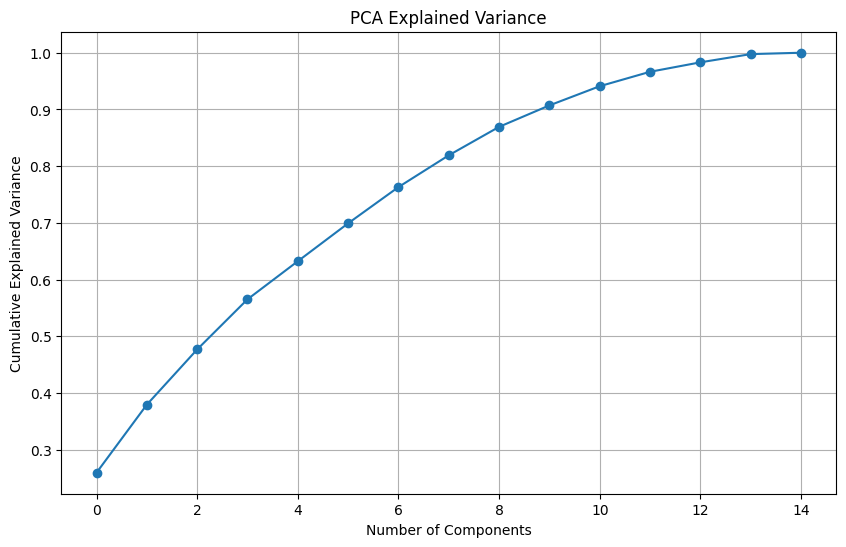

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [14]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_df)

In [15]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print(explained_variance)

[0.25941117 0.37941243 0.47675378]


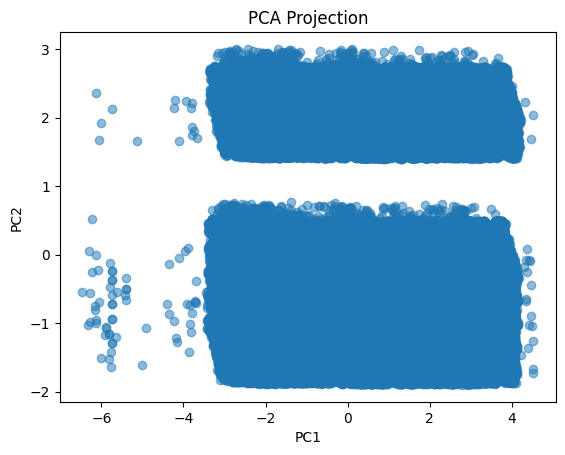

In [16]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

In [17]:
loadings = pca.components_.T

feature_importance = np.abs(loadings[:, 0])  # PC1 importance

feature_names = X.columns

importance_df = sorted(
    zip(feature_names, feature_importance),
    key=lambda x: x[1],
    reverse=True
)

print("Top 5 Features:")
for f in importance_df[:5]:
    print(f)

Top 5 Features:
('District', np.float64(0.45871093156670933))
('Beat', np.float64(0.45204757097333703))
('Ward', np.float64(0.4193755295709765))
('Latitude_Norm', np.float64(0.4160705002121945))
('Community Area', np.float64(0.3706689224818527))


In [18]:
X_scaled_df_sample = X_scaled_df.sample(10000, random_state=42)

In [19]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_df_sample)

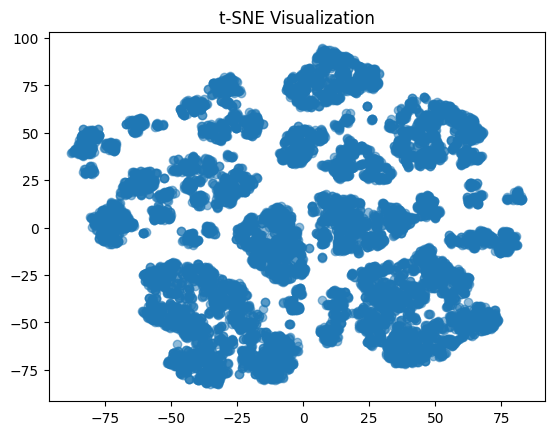

In [20]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5)
plt.title("t-SNE Visualization")
plt.show()

In [21]:
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled_df_sample)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


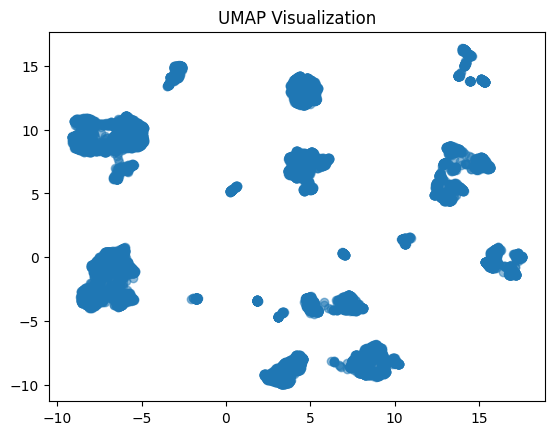

In [22]:
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5)
plt.title("UMAP Visualization")
plt.show()

In [24]:
lable_data = pd.read_pickle(
    r'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/cleaned_chicago_crime_dataset.pkl'
)

lable_data_sample = lable_data.reindex(
    X_scaled_df_sample.index
)

lable_data_sample = lable_data_sample.dropna()

In [25]:
lable_data_sample.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
756065,9543748,HX196745,2014-03-24 10:45:00,011XX N LAWNDALE AVE,0560,ASSAULT,SIMPLE,RESIDENTIAL YARD (FRONT/BACK),False,False,...,27,23,08A,1151500.0,1907416.0,2014.0,2016-02-04 06:33:39,41.901831,-87.718965,"(41.901831006, -87.718964701)"
2732901,6430023,HP510836,2008-08-13 13:15:00,008XX W VAN BUREN ST,0860,THEFT,RETAIL THEFT,GROCERY FOOD STORE,True,False,...,2,28,06,1170741.0,1898386.0,2008.0,2018-02-28 15:56:25,41.876652,-87.648555,"(41.876652229, -87.648554994)"
1830853,7834093,HS642407,2010-12-02 10:20:00,021XX E 87TH ST,0545,ASSAULT,PRO EMP HANDS NO/MIN INJURY,"SCHOOL, PUBLIC, BUILDING",True,False,...,8,45,08A,1191768.0,1847705.0,2010.0,2016-02-04 06:33:39,41.737094,-87.572998,"(41.737094305, -87.572998178)"
2661165,6557581,HP617744,2008-10-09 12:40:00,055XX S THROOP ST,1822,NARCOTICS,MANU/DEL:CANNABIS OVER 10 GMS,RESIDENCE,True,False,...,16,67,18,1168606.0,1867939.0,2008.0,2018-02-28 15:56:25,41.793149,-87.657274,"(41.793149218, -87.65727384)"
95648,10655712,HZ405613,2016-08-24 16:45:00,078XX S WOOD ST,0460,BATTERY,SIMPLE,CTA BUS,False,False,...,17,71,08B,1165718.0,1852465.0,2016.0,2018-02-10 15:50:01,41.750748,-87.668303,"(41.75074835, -87.668302608)"


In [26]:
X_scaled_df_sample.head()

,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Day_of_Week,Is_Weekend,Season,Crime_Severity_Score,Location_Desc_freq,Latitude_Norm,Longitude_Norm
2606376,0.289734,-0.602787,2.208237,0.504293,0.532477,0.380107,-0.590314,-1.398049,1.013550,1.609255,-1.342655,1.105759,0.520036,0.513683,-1.237170
756065,-1.085627,1.658962,-0.452850,0.049880,0.099508,0.307449,-0.451087,0.942531,0.508746,-0.621405,-0.424477,0.042938,-1.267835,0.484180,0.309227
2732901,0.798429,-0.602787,-0.452850,0.777227,0.821123,0.743399,-1.007994,-1.398049,-1.005667,-0.621405,0.493700,0.042938,1.394016,1.296098,-0.655276
1830853,0.289734,-0.602787,2.208237,1.634610,1.109769,1.687957,-1.472083,-0.617856,1.013550,1.609255,-1.342655,1.105759,0.520036,1.174763,0.444726
2661165,0.082488,-0.602787,-0.452850,-1.066147,-1.055077,-0.927742,0.662727,-1.398049,-0.500862,-0.621405,-1.342655,-1.019883,-1.238047,-1.691166,2.115963


In [28]:
common_idx = X_scaled_df_sample.index.intersection(
    lable_data.index
)

X_scaled_df_sample = X_scaled_df_sample.loc[common_idx]

lable_data_sample = lable_data.loc[common_idx]

In [29]:
(X_scaled_df_sample.index == lable_data_sample.index).all()

np.True_

In [33]:
common_idx = X_scaled_df_sample.index.intersection(
    lable_data.index
)

In [34]:
lable_data_sample = lable_data.loc[common_idx]

In [35]:
X_scaled_df_sample = X_scaled_df_sample.loc[common_idx]

In [37]:
common_idx = X_scaled_df_sample.index.intersection(
    lable_data.index
)

X_scaled_df_sample = X_scaled_df_sample.loc[common_idx]

lable_data_sample = lable_data.loc[common_idx]

In [38]:
print(X_scaled_df_sample.shape)

print(lable_data_sample.shape)

(9892, 15)
(9892, 22)


In [40]:
X_umap

array([[15.604034 , -0.7360675],
       [ 4.0473456,  7.665647 ],
       [-8.927357 ,  9.578122 ],
       ...,
       [ 4.6262875, 12.206299 ],
       [-2.6481383, 14.958205 ],
       [-6.4286127, -2.0781903]], shape=(10000, 2), dtype=float32)

In [44]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(
    X_scaled_df_sample
)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [45]:
X_umap.shape

(9892, 2)

In [46]:
X_umap_df = pd.DataFrame(
    X_umap,
    columns=['UMAP1', 'UMAP2'],
    index=X_scaled_df_sample.index
)

In [47]:
import plotly.express as px
import pandas as pd

# Create dataframe for plotting
plot_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'Crime_Type': lable_data_sample['Primary Type'],
    'Severity': X_scaled_df_sample['Crime_Severity_Score']
})

fig = px.scatter(
    plot_df,
    x='UMAP1',
    y='UMAP2',
    color='Crime_Type',   # or Severity
    title='UMAP Crime Clusters (Interactive)',
)

fig.show()

In [48]:
umap_3d = umap.UMAP(n_components=3, random_state=42)
X_umap_3d = umap_3d.fit_transform(X_scaled_df_sample)

plot_df['UMAP3'] = X_umap_3d[:, 2]

fig = px.scatter_3d(
    plot_df,
    x='UMAP1',
    y='UMAP2',
    z='UMAP3',
    color='Crime_Type'
)

fig.show()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
